# Skin cancer detection with MedGemma

This notebook demonstrates an AI-assisted dermatoscopic skin lesion workflow using a locally hosted `medgemma-1.5-4b-it` model exposed through the LM Studio OpenAI-compatible API.

The workflow is:
1. Load and display a dermatoscopic image.
2. Build a structured dermatology analysis prompt.
3. Send the image and prompt to MedGemma.
4. Capture and display the generated clinical-style report.


---
### Dermatoscopic image:

A **dermatoscopic image** (or dermoscopic image) is a highly specialized, magnified photograph of a skin lesion. 

While a standard "clinical" photograph shows what the eye sees, a dermatoscopic image uses a device called a **dermatoscope** to look *beneath* the surface of the skin (the stratum corneum).

#### 1. How It Works: The Physics of "Deep Seeing"
The main hurdle to seeing into the skin is light reflection. Our skin reflects most light, making it opaque. A dermatoscope solves this using two methods:
* **Polarized Light:** Modern dermatoscopes use cross-polarized filters to cancel out reflected light, allowing the lens to capture light returning from the deeper epidermis and papillary dermis.
* **Immersion Fluid:** Older "contact" methods involve placing a drop of oil or gel on the skin and pressing a glass plate against it. This "links" the skin to the lens and eliminates surface reflection.

#### 2. Clinical vs. Dermatoscopic
| Feature | Clinical Image (Phone/Camera) | Dermatoscopic Image |
| :--- | :--- | :--- |
| **Visible Depth** | Surface only | Epidermis & superficial dermis |
| **Magnification** | 1x (Variable) | 10x to 40x |
| **Key Indicators** | Color, borders, size | Pigment networks, vascular patterns |
| **Reflections** | High (Shiny skin) | None (Polarized/Fluid neutralized) |

#### 3. Usage in Cancer Detection
Dermatologists use these images to look for specific patterns that are invisible to the naked eye.
Dermatoscopic images represent one of the most successful use cases for Medical AI today:

* **The ISIC Challenge:** The "International Skin Imaging Collaboration" (ISIC) provides massive open-source datasets of these images. Most top-tier skin cancer AI models (using architectures like EfficientNet or Vision Transformers) are trained specifically on these dermatoscopic images rather than standard photos.

---

## Runtime configuration

The notebook uses the LM Studio OpenAI-compatible chat endpoint. By default it calls:

- LM_STUDIO_BASE_URL = http://192.168.1.2:1234/v1
- LM_STUDIO_MODEL = medgemma-1.5-4b-it

If your Windows host IP changes, set the LM_STUDIO_BASE_URL environment variable or update the value in the configuration cell before running the API request.

In [1]:
import base64
import mimetypes
import os
from pathlib import Path

import requests
from PIL import Image
from IPython.display import Markdown, display

Dermatological photograph taken with a standard consumer-grade camera.


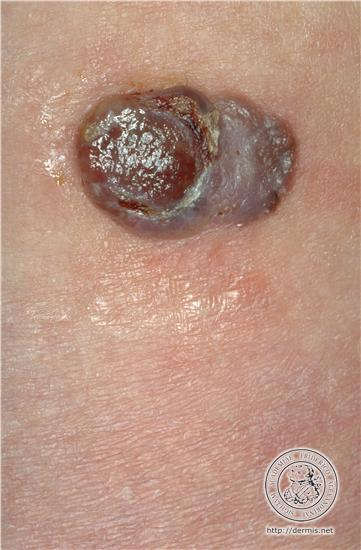

Image path: data/skin_cancer/melanoma/dermIS/SSM21_orig.jpg
Image size: 361 x 550
LM Studio endpoint: http://192.168.1.2:1234/v1
Model: medgemma-1.5-4b-it


In [2]:
LM_STUDIO_BASE_URL = os.getenv("LM_STUDIO_BASE_URL", "http://192.168.1.2:1234/v1")
LM_STUDIO_MODEL = os.getenv("LM_STUDIO_MODEL", "medgemma-1.5-4b-it")

image_path = Path("./data/skin_cancer/melanoma/dermIS/SSM21_orig.jpg")
if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path.resolve()}")

image = Image.open(image_path)
print(f"Dermatological photograph taken with a standard consumer-grade camera.")
display(image)

print(f"Image path: {image_path}")
print(f"Image size: {image.size[0]} x {image.size[1]}")
print(f"LM Studio endpoint: {LM_STUDIO_BASE_URL}")
print(f"Model: {LM_STUDIO_MODEL}")

In [4]:
prompt = """
You are an expert dermatology decision-support model reviewing a dermatoscopic skin lesion image.

Analyze the lesion and produce a concise clinician-facing report with these sections:

1. Visual findings
- Describe asymmetry, border regularity, color variation, and visible dermoscopic structures.

2. Most likely diagnosis
- Choose the single best fit from:
  - Melanoma
  - Melanocytic Nevus
  - Basal Cell Carcinoma
  - Actinic Keratosis / Bowen's Disease
  - Benign Keratosis
  - Dermatofibroma
  - Vascular Lesion

3. Diagnostic rationale
- Explain why the selected diagnosis is the best match based on the image.

4. Clinical caution
- State the main uncertainty or limitation of image-only assessment.

Keep the tone professional and medically precise. Do not overstate certainty. Make clear that this is decision support and not a confirmed diagnosis.
""".strip()

print(prompt)

You are an expert dermatology decision-support model reviewing a dermatoscopic skin lesion image.

Analyze the lesion and produce a concise clinician-facing report with these sections:

1. Visual findings
- Describe asymmetry, border regularity, color variation, and visible dermoscopic structures.

2. Most likely diagnosis
- Choose the single best fit from:
  - Melanoma
  - Melanocytic Nevus
  - Basal Cell Carcinoma
  - Actinic Keratosis / Bowen's Disease
  - Benign Keratosis
  - Dermatofibroma
  - Vascular Lesion

3. Diagnostic rationale
- Explain why the selected diagnosis is the best match based on the image.

4. Clinical caution
- State the main uncertainty or limitation of image-only assessment.

Keep the tone professional and medically precise. Do not overstate certainty. Make clear that this is decision support and not a confirmed diagnosis.


In [5]:
def encode_image_to_data_url(path: Path) -> str:
    mime_type, _ = mimetypes.guess_type(path.name)
    mime_type = mime_type or "image/jpeg"

    with path.open("rb") as image_file:
        encoded_image = base64.b64encode(image_file.read()).decode("utf-8")

    return f"data:{mime_type};base64,{encoded_image}"


def build_messages(user_prompt: str, image_data_url: str) -> list[dict]:
    return [
        {
            "role": "system",
            "content": "You are a careful multimodal medical assistant that produces concise specialist-style reports from clinical images."
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": user_prompt},
                {"type": "image_url", "image_url": {"url": image_data_url}}
            ]
        }
    ]


print("Shared LM Studio multimodal helpers are ready.")

Shared LM Studio multimodal helpers are ready.


In [ ]:
image_data_url = encode_image_to_data_url(image_path)
messages = build_messages(prompt, image_data_url)

payload = {
    "model": LM_STUDIO_MODEL,
    "messages": messages,
    "temperature": 0.2,
    "max_tokens": 700,
}

response = requests.post(
    f"{LM_STUDIO_BASE_URL}/chat/completions",
    json=payload,
    timeout=120,
)
response.raise_for_status()

response_json = response.json()
assistant_message = response_json["choices"][0]["message"]["content"]

if isinstance(assistant_message, list):
    assistant_message = "\n".join(
        part.get("text", "") for part in assistant_message if part.get("type") == "text"
    ).strip()

report_markdown = "\n".join([
    "## MedGemma Clinical Report",
    "",
    assistant_message,
])

display(Markdown(report_markdown))

## MedGemma Clinical Report

FINDINGS: The lesion is an exophytic, dome-shaped papule with irregular borders. There is color variation present, including shades of brown, black, and red/pink areas. Dermoscopic structures include a prominent central area with homogenous dark brown pigmentation and possibly some structureless areas. Peripheral areas show less distinct features but appear slightly raised and erythematous. No clear network pattern or specific vascular structures are readily identifiable in the provided image resolution.

DIAGNOSIS: Melanocytic Nevus

RATIONALE: The lesion exhibits features consistent with a melanocytic nevus, including its overall morphology (dome-shaped papule), presence of brown/black pigmentation, and relatively organized structure centrally. While some asymmetry and color variation are present, they can be seen in benign nevi as well.

CAUTION: Image quality limits detailed assessment of subtle dermoscopic features. Clinical correlation and potentially biopsy are necessary for definitive diagnosis.

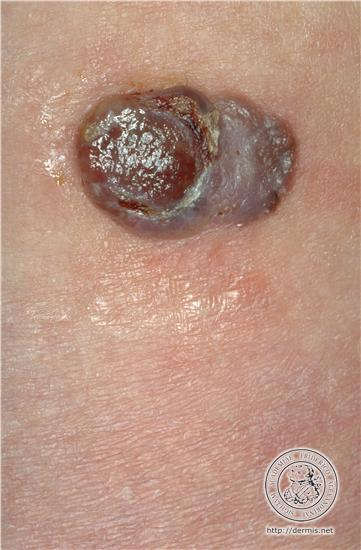

In [10]:
display(image)

## AI powered cancer detection using histopathology images

Histopathology images are high-resolution digital captures of thin slices of biological tissue that have been chemically stained and placed on glass slides. While a scan (like an MRI or CT) looks at the "macro" structure of the body, histopathology looks at the cellular level. In the medical world, a histopathology report is considered the "Gold Standard" for diagnosing cancer.

### 1. How the Images are Created
The process of moving from a patient to a digital image involves several steps:
* **Biopsy:** A small piece of tissue is removed from the patient.
* **Fixation and Slicing:** The tissue is hardened (usually in paraffin wax) and cut into slices thinner than a human hair (about 4–5 microns).
* **Staining (H&E):** The slices are clear, so they are dyed with **Hematoxylin** (which turns cell nuclei deep blue/purple) and **Eosin** (which turns the rest of the cell structures pink/red).
* **Digitization:** A Whole Slide Imaging (WSI) scanner captures these slides at 20x or 40x magnification, creating massive image files (often several gigabytes each).

### 2. How They Are Used for Cancer Detection
Pathologists (and increasingly, AI models) analyze these images to find structural "clues" that indicate malignancy:

#### **Cellular Abnormality**
In healthy tissue, cells are uniform. In cancer, cells often have:
* **Large, irregular nuclei:** The "brain" of the cell becomes enlarged and dark.
* **Increased Mitosis:** You can see cells in the middle of dividing, indicating rapid, uncontrolled growth.

#### **Tissue Architecture**
Cancer disrupts the natural "neighborhood" of cells. 
* **Infiltration:** Instead of staying within their boundary (like the lining of a duct), cancer cells break through and invade surrounding healthy tissue.
* **Loss of Differentiation:** High-grade cancer cells look nothing like the original tissue they came from; they become a chaotic "sheet" of cells.

### 3. The Role of AI and ML (Computational Pathology)
As an AI/ML engineer, this is where the field gets exciting. Because these images are so large ($50,000 \times 50,000$ pixels or more), humans can miss tiny "micrometastases." 

* **Patch-Based Classification:** Since the images are too big for a standard GPU's VRAM, they are broken into smaller "patches" (e.g., $224 \times 224$). A CNN or Transformer model classifies each patch as "Tumor" or "Normal."
* **Automated Grading:** AI can quantify exactly how many mitotic cells are present or measure the surface area of a tumor more accurately than a human eye.
* **Segmentation:** Drawing precise boundaries around a tumor helps surgeons or radiologists plan treatments.

#### Comparison: Radiology vs. Histopathology

| Feature | Radiology (CT/MRI/X-ray) | Histopathology (WSI) |
| :--- | :--- | :--- |
| **View** | Macroscopic (Organs/Bones) | Microscopic (Cells) |
| **Purpose** | Locate a mass or abnormality | Determine if the mass is cancerous |
| **Magnification** | 1x | 20x to 40x |
| **Data Format** | DICOM | SVS, TIFF, NDPI |

## Histopathology image analysis with MedGemma

This section mirrors the dermatoscopic workflow, but uses a histopathology slide patch. The notebook will:

1. Load a sample histopathology image.
2. Send the image and a pathology-focused prompt to MedGemma.
3. Render the returned report in the notebook.

Histopathology image patch from the MoNuSeg-style dataset.


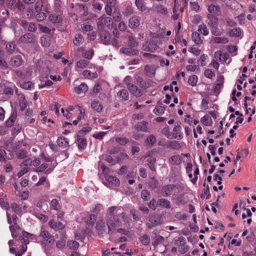

Image path: data/processed-original-monuseg/train_folder/img/0001.png
Image size: 256 x 256


In [6]:
histopathology_candidates = [
    Path("./data/processed-original-monuseg/train_folder/img/001.png"),
    Path("./data/processed-original-monuseg/train_folder/img/0001.png"),
]

histopathology_image_path = next(
    (candidate for candidate in histopathology_candidates if candidate.exists()),
    None,
)
if histopathology_image_path is None:
    searched = "\n".join(str(candidate.resolve()) for candidate in histopathology_candidates)
    raise FileNotFoundError(f"No histopathology sample image found. Checked:\n{searched}")

histopathology_image = Image.open(histopathology_image_path)
print("Histopathology image patch from the MoNuSeg-style dataset.")
display(histopathology_image)

print(f"Image path: {histopathology_image_path}")
print(f"Image size: {histopathology_image.size[0]} x {histopathology_image.size[1]}")

In [7]:
histopathology_prompt = """
You are a highly specialized AI pathologist. Analyze the histopathology image and classify the type of cells or tissue abnormality present.
If possible, describe if there are signs of cancer or other cellular anomalies.
Respond in a concise medical style suitable for pathology reports.
""".strip()

print(histopathology_prompt)

You are a highly specialized AI pathologist. Analyze the histopathology image and classify the type of cells or tissue abnormality present.
If possible, describe if there are signs of cancer or other cellular anomalies.
Respond in a concise medical style suitable for pathology reports.


In [8]:
histopathology_image_data_url = encode_image_to_data_url(histopathology_image_path)
histopathology_messages = build_messages(histopathology_prompt, histopathology_image_data_url)

histopathology_payload = {
    "model": LM_STUDIO_MODEL,
    "messages": histopathology_messages,
    "temperature": 0.2,
    "max_tokens": 700,
}

histopathology_response = requests.post(
    f"{LM_STUDIO_BASE_URL}/chat/completions",
    json=histopathology_payload,
    timeout=120,
)
histopathology_response.raise_for_status()

histopathology_response_json = histopathology_response.json()
histopathology_assistant_message = histopathology_response_json["choices"][0]["message"]["content"]

if isinstance(histopathology_assistant_message, list):
    histopathology_assistant_message = "\n".join(
        part.get("text", "")
        for part in histopathology_assistant_message
        if part.get("type") == "text"
    ).strip()

histopathology_report_markdown = "\n".join([
    "## MedGemma Histopathology Report",
    "",
    histopathology_assistant_message,
])

display(Markdown(histopathology_report_markdown))

## MedGemma Histopathology Report

**Histopathology Report:**

The image displays glandular epithelium with marked atypia, including enlarged nuclei, prominent nucleoli, and irregular nuclear contours. There is evidence of architectural disarray with loss of normal gland formation. These features are suggestive of malignancy. Further immunohistochemical studies are recommended for definitive diagnosis.